In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def read_json_data(num):
    df = pd.read_json(f"../data/analysis_{num}.json")
    # flatten 'patterns' array into rows
    df_patterns = df.explode('patterns').dropna(subset=['patterns'])
    # flatten objects {pattern, count} into columns
    df_patterns[['pattern', 'count']] = df_patterns['patterns'].apply(pd.Series)
    return df, df_patterns
    
def pattern_summary(df_patterns):
    pattern_count = df_patterns['pattern'].unique().size
    print(f"Number of unique patterns: {pattern_count}")
    
    # number of unique repos per pattern
    pattern_counts = df_patterns.groupby('pattern')['full_name'].nunique().sort_values(ascending=False)
    print(pattern_counts)

    # total occurences per pattern
    pattern_totals = df_patterns.groupby('pattern')['count'].sum().sort_values(ascending=False)
    print(pattern_totals)
    
def analyze_sample(num: int):
    df, df_patterns = read_json_data(num)
    
    print(f"Total repos: {len(df)}")
    print(f"Repos with at least one pattern: {df['patterns'].apply(len).gt(0).sum()}")
    print(f"Repos with no patterns: {df['patterns'].apply(len).eq(0).sum()}")
    
    pattern_summary(df_patterns)

In [127]:
def compare_runs():
    runs = {}
    for num in [1, 2, 3]:
        df, df_patterns = read_json_data(num)
        runs[f"v{num}"] = df_patterns.groupby('pattern')['full_name'].nunique()
        
    comparison = pd.DataFrame(runs).fillna(0)
    comparison.plot(kind='bar', figsize=(14, 6))
    plt.title("Pattern frequency across refinement iterations")
    plt.ylabel("Number of repos")
    plt.tight_layout()
    plt.savefig("pattern_refinement.png", dpi=150)
    plt.show()

In [118]:
analyze_sample(1)

Total repos: 172
Repos with at least one pattern: 169
Repos with no patterns: 3
Number of unique patterns: 19
pattern
reduce                   143
par_iter                 142
unzip                     91
ThreadPool                85
ThreadPoolBuilder         82
par_bridge                39
par_sort                  31
rayon::spawn              31
rayon::scope              25
par_chunks                24
rayon::join               20
par_sort_by               16
impl ParallelIterator     11
flat_map_iter              9
par_extend                 9
par_sort_by_key            6
rayon::broadcast           2
scope_fifo                 2
par_windows                1
Name: full_name, dtype: int64
pattern
reduce                   16985
par_iter                  3339
ThreadPool                1349
unzip                     1293
ThreadPoolBuilder          551
par_sort                   254
par_chunks                 213
par_bridge                 151
par_extend                 104
rayon::spawn  

In [119]:
analyze_sample(2)

Total repos: 172
Repos with at least one pattern: 156
Repos with no patterns: 16
Number of unique patterns: 11
pattern
.par_iter()                 142
rayon::ThreadPool            75
rayon::ThreadPoolBuilder     73
.par_bridge()                39
.par_sort()                  31
rayon::spawn                 31
rayon::scope                 25
rayon::join                  20
impl ParallelIterator        11
rayon::broadcast              2
rayon::scope_fifo             2
Name: full_name, dtype: int64
pattern
.par_iter()                 3333
rayon::ThreadPool            381
.par_sort()                  254
rayon::ThreadPoolBuilder     245
.par_bridge()                151
rayon::spawn                  94
rayon::join                   91
rayon::scope                  71
impl ParallelIterator         29
rayon::scope_fifo              4
rayon::broadcast               2
Name: count, dtype: int64


In [120]:
analyze_sample(3)

Total repos: 172
Repos with at least one pattern: 158
Repos with no patterns: 14
Number of unique patterns: 17
pattern
.par_iter                   142
rayon::ThreadPool            75
rayon::ThreadPoolBuilder     73
.par_bridge                  39
.par_sort                    31
rayon::spawn                 31
rayon::scope                 25
.par_chunks                  24
rayon::join                  20
.par_sort_by                 16
impl ParallelIterator        11
.flat_map_iter                9
.par_extend                   9
.par_sort_by_key              6
rayon::broadcast              2
rayon::scope_fifo             2
.par_windows                  1
Name: full_name, dtype: int64
pattern
.par_iter                   3333
rayon::ThreadPool            381
.par_sort                    254
rayon::ThreadPoolBuilder     245
.par_chunks                  213
.par_bridge                  151
.par_extend                  104
rayon::spawn                  94
rayon::join                   91
ra

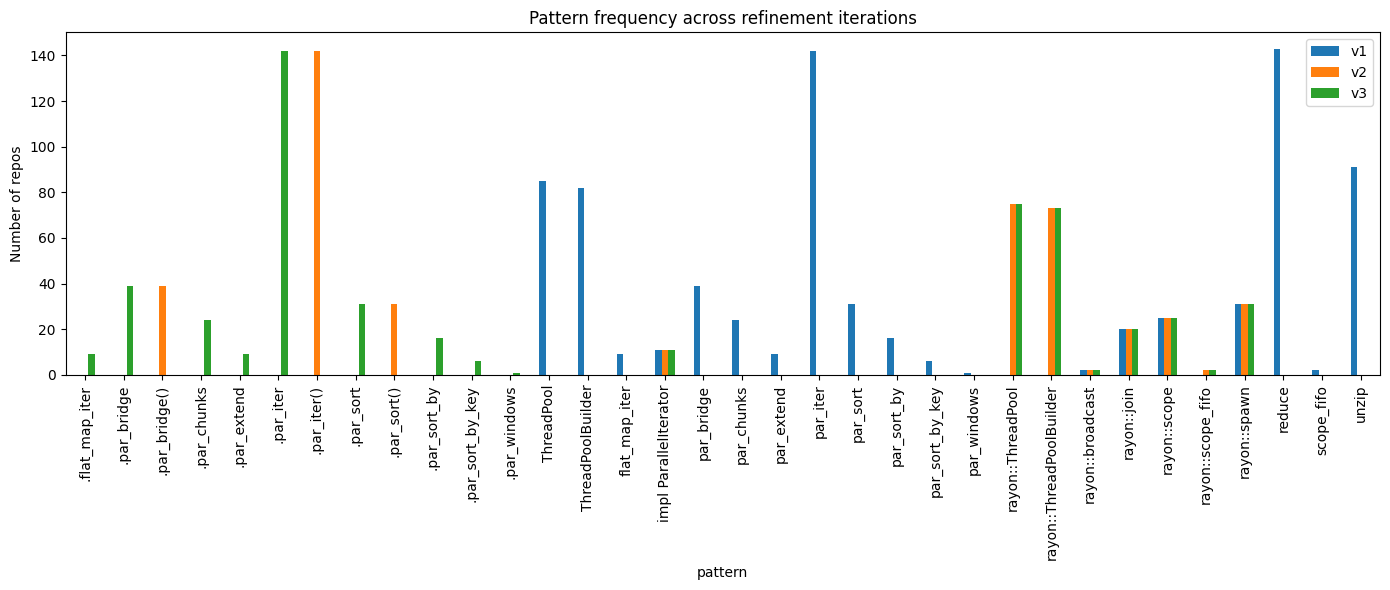

In [128]:
compare_runs()